[*********************100%***********************]  5 of 5 completed


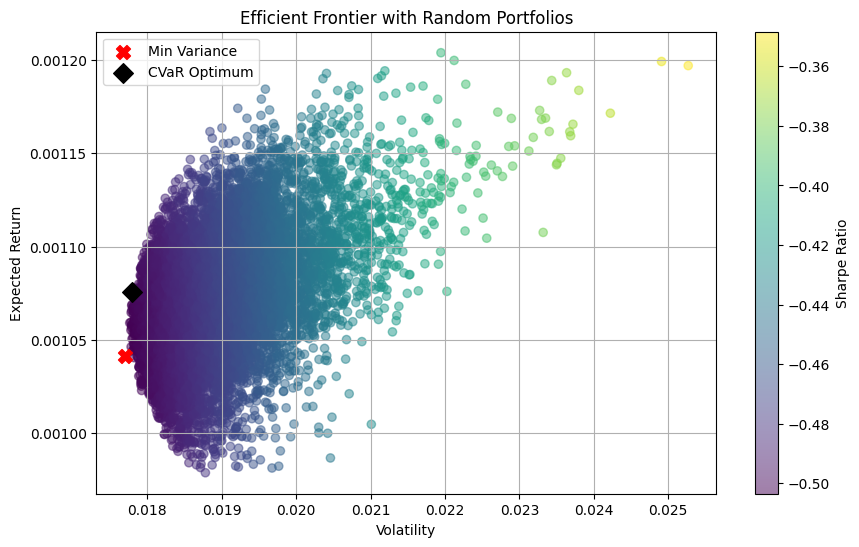

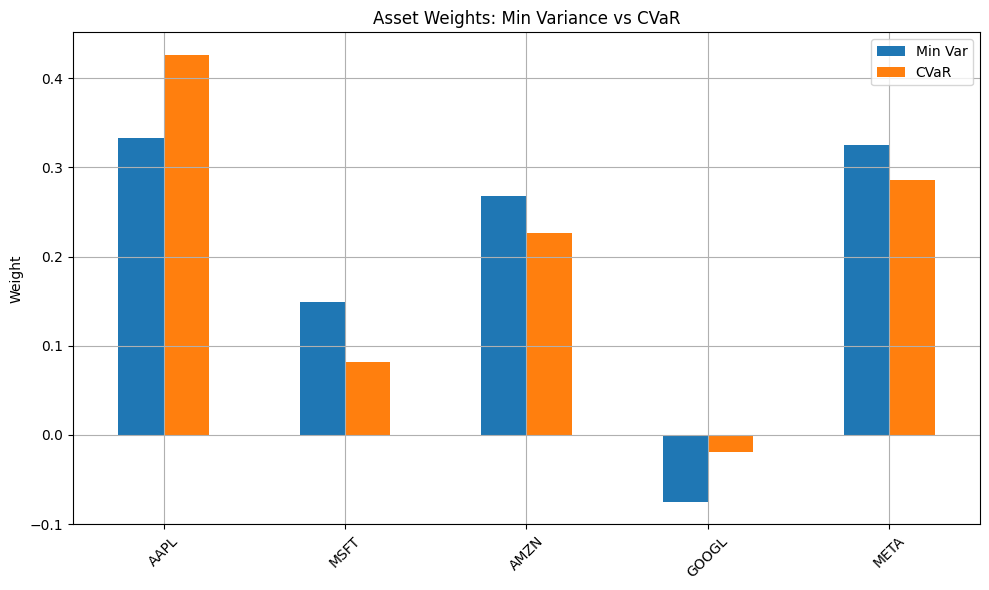

In [3]:
# Instala las dependencias si estás en Google Colab
!pip install yfinance cvxpy

# 📦 Importación de librerías
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# 🎯 Definir activos y período
assets = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META']
start_date = '2020-01-01'
end_date = '2024-12-31'

# 📥 Descargar precios ajustados correctamente
data = yf.download(assets, start=start_date, end=end_date, auto_adjust=True)

# Comprobamos si 'Close' es un MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    adj_close = data['Close']  # Con auto_adjust=True, 'Close' actúa como 'Adj Close'
else:
    adj_close = data['Close'] if 'Close' in data.columns else data

# 📈 Calcular retornos diarios
returns = adj_close.pct_change().dropna()
mean_returns = returns.mean()
cov_matrix = returns.cov()

# ⚙️ Simulación de portafolios aleatorios
num_portfolios = 10_000
risk_free_rate = 0.01

results = {'Returns': [], 'Volatility': [], 'Sharpe': [], 'Weights': []}
for _ in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)
    port_return = np.dot(weights, mean_returns)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (port_return - risk_free_rate) / port_volatility
    results['Returns'].append(port_return)
    results['Volatility'].append(port_volatility)
    results['Sharpe'].append(sharpe_ratio)
    results['Weights'].append(weights)

portfolios = pd.DataFrame(results)

# 📌 Optimización de mínima varianza (Markowitz)
w = cp.Variable(len(assets))
risk = cp.quad_form(w, cov_matrix.values)
prob = cp.Problem(cp.Minimize(risk), [cp.sum(w) == 1])
prob.solve()
min_var_weights = w.value

# 📌 Optimización con CVaR
alpha = 0.95
scenarios = returns.values
w_cvar = cp.Variable(len(assets))
VaR = cp.Variable()
u = cp.Variable(len(scenarios))
portfolio_returns = scenarios @ w_cvar

cvar_obj = VaR + (1 / ((1 - alpha) * len(scenarios))) * cp.sum(u)
constraints = [
    cp.sum(w_cvar) == 1,
    mean_returns.values.T @ w_cvar >= portfolios['Returns'].mean(),
    u >= 0,
    u >= -portfolio_returns - VaR
]
problem_cvar = cp.Problem(cp.Minimize(cvar_obj), constraints)
problem_cvar.solve()
cvar_weights = w_cvar.value

# 📊 Frontera eficiente con puntos óptimos
plt.figure(figsize=(10, 6))
plt.scatter(portfolios['Volatility'], portfolios['Returns'], c=portfolios['Sharpe'], cmap='viridis', alpha=0.5)
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Random Portfolios')
plt.colorbar(label='Sharpe Ratio')

min_var_return = np.dot(min_var_weights, mean_returns)
min_var_vol = np.sqrt(np.dot(min_var_weights.T, np.dot(cov_matrix, min_var_weights)))
plt.scatter(min_var_vol, min_var_return, color='red', label='Min Variance', marker='X', s=100)

cvar_return = np.dot(cvar_weights, mean_returns)
cvar_vol = np.sqrt(np.dot(cvar_weights.T, np.dot(cov_matrix, cvar_weights)))
plt.scatter(cvar_vol, cvar_return, color='black', label='CVaR Optimum', marker='D', s=100)

plt.legend()
plt.grid(True)
plt.show()

# 📊 Pesos óptimos por modelo
min_var_weights_df = pd.Series(min_var_weights, index=assets, name="Min Var")
cvar_weights_df = pd.Series(cvar_weights, index=assets, name="CVaR")
weight_df = pd.concat([min_var_weights_df, cvar_weights_df], axis=1)

weight_df.plot(kind='bar', figsize=(10, 6), title='Asset Weights: Min Variance vs CVaR')
plt.ylabel('Weight')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
!pip install yfinance cvxpy

import yfinance as yf
import pandas as pd
import numpy as np
import cvxpy as cp

# Activos y fechas
assets = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META']
start_date = '2020-01-01'
end_date = '2024-12-31'

# Descargar datos y ajustar
data = yf.download(assets, start=start_date, end=end_date, auto_adjust=True)
adj_close = data['Close'] if isinstance(data.columns, pd.MultiIndex) else data
returns = adj_close.pct_change().dropna()

# Estadísticas básicas
mean_returns = returns.mean()
cov_matrix = returns.cov()
correlation_matrix = returns.corr()
annualized_returns = mean_returns * 252
annualized_cov = cov_matrix * 252

print("=== 🔢 Estadísticas Básicas ===\n")
print("Rendimientos esperados anuales:")
print(annualized_returns.round(4))
print("\nMatriz de covarianza anualizada:")
print(annualized_cov.round(4))
print("\nMatriz de correlación:")
print(correlation_matrix.round(2))

# --- 1️⃣ Portafolio de mínima varianza ---
w_minvar = cp.Variable(len(assets))
risk_minvar = cp.quad_form(w_minvar, annualized_cov.values)
constraints_minvar = [cp.sum(w_minvar) == 1]
prob_minvar = cp.Problem(cp.Minimize(risk_minvar), constraints_minvar)
prob_minvar.solve()
weights_minvar = pd.Series(w_minvar.value, index=assets)

# --- 2️⃣ Portafolio con retorno objetivo ---
target_return = 0.20  # 20% anual
w_target = cp.Variable(len(assets))
risk_target = cp.quad_form(w_target, annualized_cov.values)
constraints_target = [
    cp.sum(w_target) == 1,
    mean_returns.values.T @ w_target * 252 >= target_return
]
prob_target = cp.Problem(cp.Minimize(risk_target), constraints_target)
prob_target.solve()
weights_target = pd.Series(w_target.value, index=assets)

# --- 3️⃣ Portafolio con restricciones prácticas ---
w_restricted = cp.Variable(len(assets))
constraints_restricted = [
    cp.sum(w_restricted) == 1,
    w_restricted >= 0.05,
    w_restricted <= 0.40
]
risk_restricted = cp.quad_form(w_restricted, annualized_cov.values)
prob_restricted = cp.Problem(cp.Minimize(risk_restricted), constraints_restricted)
prob_restricted.solve()
weights_restricted = pd.Series(w_restricted.value, index=assets)

# --- 📊 Comparativa numérica ---
def portfolio_stats(weights, mu, cov):
    ret = np.dot(weights, mu) * 252
    vol = np.sqrt(np.dot(weights, np.dot(cov, weights))) * np.sqrt(252)
    sharpe = (ret - 0.01) / vol
    return pd.Series({'Retorno': ret, 'Volatilidad': vol, 'Sharpe': sharpe})

print("\n=== 📈 Portafolio: Mínima Varianza ===")
print(weights_minvar.round(4))
print(portfolio_stats(weights_minvar, mean_returns, cov_matrix).round(4))

print("\n=== 🎯 Portafolio: Retorno Objetivo 20% ===")
print(weights_target.round(4))
print(portfolio_stats(weights_target, mean_returns, cov_matrix).round(4))

print("\n=== 🔒 Portafolio: Restricciones prácticas (5%-40%) ===")
print(weights_restricted.round(4))
print(portfolio_stats(weights_restricted, mean_returns, cov_matrix).round(4))

# --- Análisis de sensibilidad ---
print("\n=== 📉 Análisis de sensibilidad: cambios en retorno esperado ===")
delta_mu = mean_returns.copy()
delta_mu['AAPL'] += 0.01  # Simulamos mejora en Apple

new_weights = cp.Variable(len(assets))
new_risk = cp.quad_form(new_weights, annualized_cov.values)
constraints_new = [cp.sum(new_weights) == 1]
new_prob = cp.Problem(cp.Minimize(new_risk), constraints_new)
new_prob.solve()
new_w = pd.Series(new_weights.value, index=assets)

print("Nueva asignación si se espera mejor rendimiento en AAPL:")
print(new_w.round(4))


[*********************100%***********************]  5 of 5 completed


=== 🔢 Estadísticas Básicas ===

Rendimientos esperados anuales:
Ticker
AAPL     0.2995
AMZN     0.2346
GOOGL    0.2598
META     0.3109
MSFT     0.2507
dtype: float64

Matriz de covarianza anualizada:
Ticker    AAPL    AMZN   GOOGL    META    MSFT
Ticker                                        
AAPL    0.1004  0.0675  0.0668  0.0801  0.0723
AMZN    0.0675  0.1294  0.0757  0.0984  0.0745
GOOGL   0.0668  0.0757  0.1057  0.0936  0.0740
META    0.0801  0.0984  0.0936  0.2017  0.0849
MSFT    0.0723  0.0745  0.0740  0.0849  0.0931

Matriz de correlación:
Ticker  AAPL  AMZN  GOOGL  META  MSFT
Ticker                               
AAPL    1.00  0.59   0.65  0.56  0.75
AMZN    0.59  1.00   0.65  0.61  0.68
GOOGL   0.65  0.65   1.00  0.64  0.75
META    0.56  0.61   0.64  1.00  0.62
MSFT    0.75  0.68   0.75  0.62  1.00

=== 📈 Portafolio: Mínima Varianza ===
AAPL     0.3325
MSFT     0.1495
AMZN     0.2681
GOOGL   -0.0751
META     0.3251
dtype: float64
Retorno        0.2625
Volatilidad    0.2809
Sha